## Introduction

**KDD (Knowledge Discovery in Databases)** is the process of extracting useful knowledge from data. This notebook illustrates the **5 main phases** of the KDD process using the scikit-learn library.

### The 5 Phases of KDD

1. **Selection** - Identification and collection of relevant data
2. **Preprocessing** - Data cleaning (missing values, outliers, noise)
3. **Transformation** - Dimensionality reduction, normalization, feature engineering
4. **Data Mining** - Applying algorithms to extract patterns
5. **Interpretation/Evaluation** - Analysis and validation of results

---
## Setup and Library Imports

In [ ]:
# fundamental libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - Dataset
from sklearn.datasets import load_iris

# Scikit-learn - Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Scikit-learn - Feature Selection and Transformation
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# Scikit-learn - Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Scikit-learn - Classificarion Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


# Scikit-learn - Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report)

# Graphical settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Reproducibility
np.random.seed(42)

---
## PHASE 1: Data Selection

In this phase we identify and load the relevant data for our problem. We will use the **Iris** dataset as a didactic example.

In [ ]:
# Iris dataset loading
iris = load_iris()

# Creation of the DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset Iris loaded!")
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nFeatures: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")

Dataset Iris caricato!
Dimensioni: 150 righe x 6 colonne

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classi target: ['setosa' 'versicolor' 'virginica']


In [ ]:
# Initial data exploration
print("First 10 rows of the dataset:")
df.head(10)

Prime 10 righe del dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


Let's now look at some information about the dataframe using the **_.info()_** method.

**_df.info()_** prints a concise summary of the DataFrame. In particular it shows:

- The object type (DataFrame)
- The RangeIndex — total number of rows
- The columns — name, non-null value count, and data type (dtype) for each
- The data types present — a summary of the dtypes used
- Memory usage — how much space the DataFrame occupies in RAM

In [ ]:
# Dataset information
print("Dataset information:")
df.info()

Informazioni sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# Descriptive statistics
print("Descriptive statistics:")
df.describe()

Statistiche descrittive:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Distribuzione delle classi:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


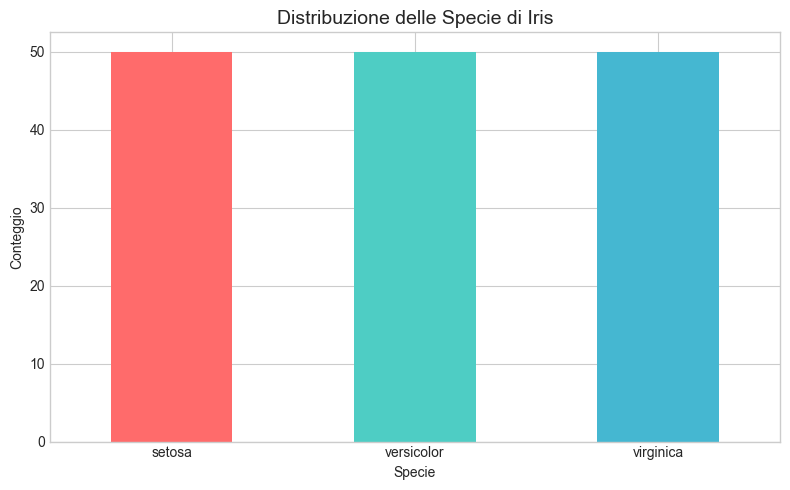

In [12]:
# Distribution of classes
print("Distribution of classes:")
print(df['species'].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))
df['species'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'], ax=ax)
ax.set_title('Distribution of Iris Species', fontsize=14)
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()

plt.show()

---
## PHASE 2: Data Preprocessing

This phase includes data cleaning: handling missing values, removing duplicates, and managing outliers.

### 2.1 Missing Values Check

In [17]:
# Missing Values Check
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Valori mancanti per colonna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Totale valori mancanti: 0


Let's create some artificial missing values in our dataset, so we can demonstrate the imputation phase in Scikit-Learn.

The steps are as follows:
1. We will copy the dataframe, to work on an independent copy;
2. We will iterate over the dataframe columns, specifically those representing features;
3. We will randomly select rows for each column and set their value to _nan_

In [21]:
# We simulate missing values to demonstrate imputation
df_with_missing = df.copy()

# We introduce some random missing values
np.random.seed(42)
for col in iris.feature_names:
    col_mask = np.random.random(len(df_with_missing)) < 0.05
    df_with_missing.loc[col_mask, col] = np.nan

print("Dataset with simulated missing values:")
print(df_with_missing.isnull().sum())

Dataset con valori mancanti simulati:
sepal length (cm)    9
sepal width (cm)     9
petal length (cm)    9
petal width (cm)     9
target               0
species              0
dtype: int64


**Deep Dive**: What does:
``
col_mask = np.random.random(len(df_with_missing)) < 0.05
``do?

Let's break the code into parts to better understand it:

1. ``
np.random.random(len(df_with_missing))
`` creates an array of random values between 0 and 1, with length equal to the number of rows
2. ``< 0.05`` creates a boolean mask where approximately 5% of values are True

So, imagining we have 5 rows, a possible array created in step 1 could be:

```python 
[0.64, 0.03, 0.35, 0.04, 0.57]
```

Subsequently, through the comparison performed in step 2, this array is converted into a binary mask:

```python 
[False, True, False, True, False]
```

Finally, ```df_with_missing.loc[col_mask, col] = np.nan``` is responsible for replacing with _nan_ the values of column _col_ for the rows where _col_mask_ is _True_.

At this point we can use a Scikit-Learn _Transformer_: the _SimpleImputer_.

This object replaces missing values according to a specific _strategy_ to be specified:
- mean: uses the mean of the present values;
- median: uses the median of the present values;
- most_frequent: uses the mode of the present values;
- constant: uses a constant value, which must be specified through the _fill_value_ attribute

**Note**:
- imputers always return a numpy array, so it will be our responsibility to (optionally) convert the output back into a Pandas DataFrame
- when using _mean_ or _median_ make sure that the columns being imputed are actually numeric, otherwise an error will occur.

In [ ]:
# Imputation of missing values with SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Other strategies: 'median', 'most_frequent', 'constant'

# Apply only to numeric columns
X_imputed = imputer.fit_transform(df_with_missing[iris.feature_names])
df_imputed = pd.DataFrame(X_imputed, columns=iris.feature_names)
df_imputed['target'] = df_with_missing['target']
df_imputed['species'] = df_with_missing['species']

print("After imputation:")
print(df_imputed.isnull().sum())

<class 'numpy.ndarray'>
Dopo imputation:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


### 2.2 Duplicate Check and Removal

Pandas provides a simple function to check for duplicate rows: _duplicated()_.

Normally, a row is flagged as a duplicate starting from the second occurrence. By using the _keep=False_ parameter, the first occurrence of the row can also be flagged as a duplicate.

Similarly, Pandas provides a simple function to remove duplicates: _drop_duplicates()_. (The same note about the _keep=False_ parameter applies here as well).

In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)])
    
    # Removal of duplicates
    df_clean = df.drop_duplicates()
    print(f"\nDimensions after removing duplicates: {df_clean.shape}")

Numero di righe duplicate: 1

Righe duplicate:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
101                5.8               2.7                5.1               1.9   
142                5.8               2.7                5.1               1.9   

     target    species  
101       2  virginica  
142       2  virginica  

Dimensioni dopo rimozione duplicati: (149, 6)


### 2.3 Outlier Detection

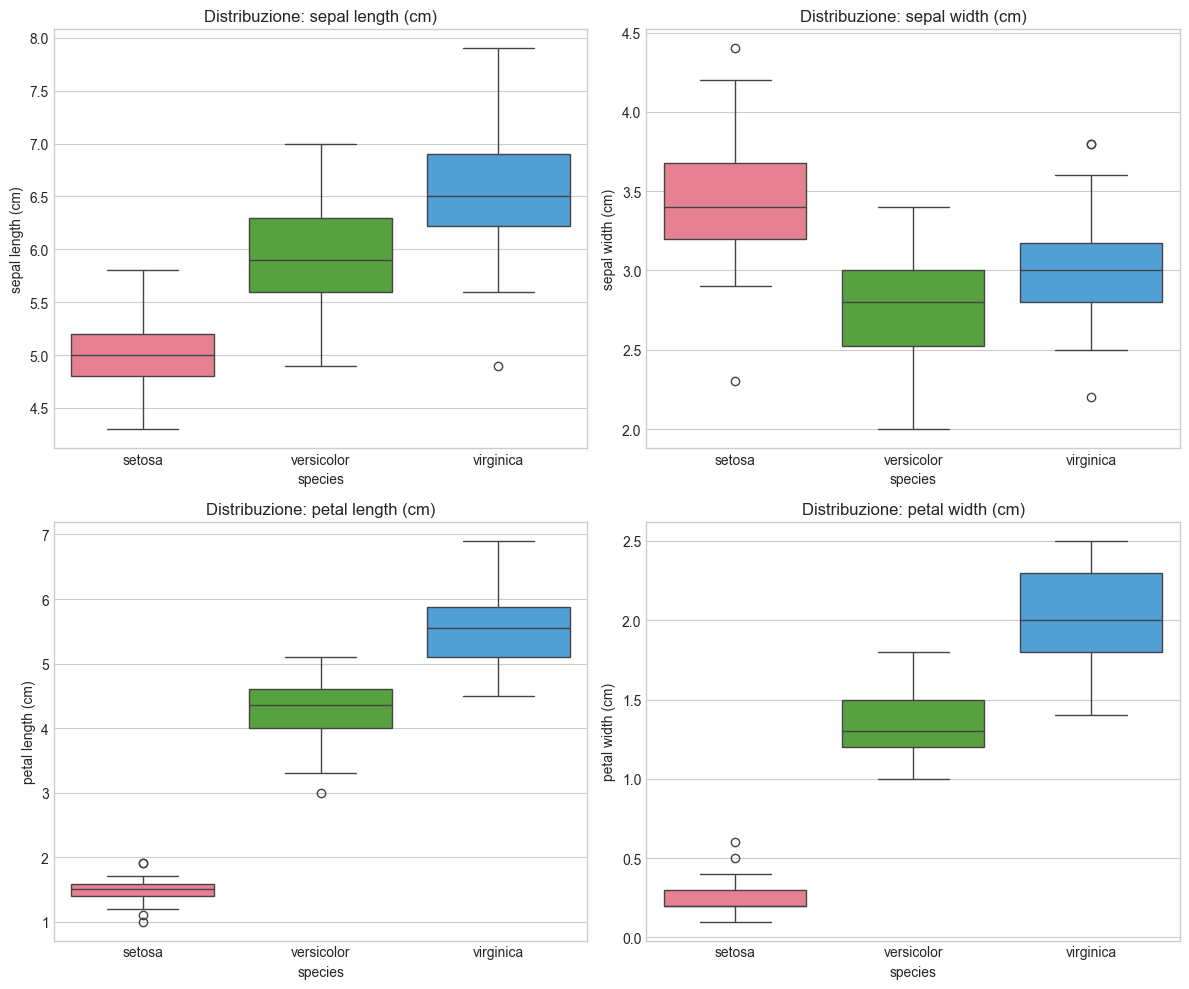

In [ ]:
# Outlier visualization with boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x='species', y=col, ax=ax, palette='husl', hue='species', legend=False)
    ax.set_title(f'Distribuzione: {col}')

plt.tight_layout()
plt.show()

**Deep Dive**: What is the purpose of:
``
    ax = axes[idx // 2, idx % 2]
``
in the code?
<details>
<summary>Answer</summary>
It converts a linear index (0, 1, 2, 3) into coordinates of a 2x2 grid.

Let's look at the code:
```python
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
```

We are creating a 2x2 grid, where the indices can be:
| axes  | Position  |
|---|---|
| 0,0 | first row, first column |
| 0,1 | first row, second column |
| 1,0 | second row, first column |
| 1,1 | second row, second column |


Subsequently, with
```python
for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
```
We iterate over the columns, each with its own "linear" index:
| idx  | col  |
|---|---|
| 0 | Sepal Length |
| 1 | Sepal Width |
| 2 | Petal Length |
| 3 | Petal Width |

This is where the **`//`** and **`%`** operators come into play:
**`//` is integer division**, **`%` is the remainder (modulo)**.

Let's see what happens for each value of `idx`:

| idx | idx // 2 (row) | idx % 2 (column) | position |
|-----|-----------------|-------------------|-----------|
| 0   | 0               | 0                 | axes[0,0] |
| 1   | 0               | 1                 | axes[0,1] |
| 2   | 1               | 0                 | axes[1,0] |
| 3   | 1               | 1                 | axes[1,1] |

So:

- `idx // 2` returns the row (0, 0, 1, 1)
- `idx % 2` returns the column (0, 1, 0, 1)

</details>

In [ ]:
# IQR method for identifying outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


print("Outlier identificati (metodo IQR):")
for species in df['species'].unique():
    for col in iris.feature_names:
        subset = df[df['species'] == species]
        outliers, lb, ub = detect_outliers_iqr(subset, col)
        print(f"{species} - {col}: {len(outliers)} outlier (bounds: [{lb:.2f}, {ub:.2f}])")

Outlier identificati (metodo IQR):
setosa - sepal length (cm): 0 outlier (bounds: [4.20, 5.80])
setosa - sepal width (cm): 2 outlier (bounds: [2.49, 4.39])
setosa - petal length (cm): 4 outlier (bounds: [1.14, 1.84])
setosa - petal width (cm): 2 outlier (bounds: [0.05, 0.45])
versicolor - sepal length (cm): 0 outlier (bounds: [4.55, 7.35])
versicolor - sepal width (cm): 0 outlier (bounds: [1.81, 3.71])
versicolor - petal length (cm): 1 outlier (bounds: [3.10, 5.50])
versicolor - petal width (cm): 0 outlier (bounds: [0.75, 1.95])
virginica - sepal length (cm): 1 outlier (bounds: [5.21, 7.91])
virginica - sepal width (cm): 3 outlier (bounds: [2.24, 3.74])
virginica - petal length (cm): 0 outlier (bounds: [3.94, 7.04])
virginica - petal width (cm): 0 outlier (bounds: [1.05, 3.05])


---
## PHASE 3: Data Transformation

Includes normalization, standardization, dimensionality reduction and feature engineering.

### 3.1 Normalization and Standardization

In [ ]:
# Let's prepare the data
X = df[iris.feature_names].values
y = df['target'].values

print("Original data (first 5 rows):")
print(pd.DataFrame(X[:5], columns=iris.feature_names))

Dati originali (prime 5 righe):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
# StandardScaler: mean=0, std=1 (Z-score normalization)
scaler_standard = StandardScaler()
X_standardized = scaler_standard.fit_transform(X)

print("After StandardScaler (Z-score):")
print(f"Mean per feature: {X_standardized.mean(axis=0).round(2)}")
print(f"Std per feature: {X_standardized.std(axis=0).round(2)}")
print("\nFirst 5 rows:")
print(pd.DataFrame(X_standardized[:5], columns=iris.feature_names).round(3))

Dopo StandardScaler (Z-score):
Media per feature: [-0. -0. -0. -0.]
Std per feature: [1. 1. 1. 1.]

Prime 5 righe:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0             -0.901             1.019             -1.340            -1.315
1             -1.143            -0.132             -1.340            -1.315
2             -1.385             0.328             -1.397            -1.315
3             -1.507             0.098             -1.283            -1.315
4             -1.022             1.249             -1.340            -1.315


In [ ]:
# MinMaxScaler: scales  data in the interval [0, 1]
scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X)

print("After MinMaxScaler [0, 1]:")
print(f"Min per feature: {X_normalized.min(axis=0)}")
print(f"Max per feature: {X_normalized.max(axis=0)}")
print("\nFirst 5 rows:")
print(pd.DataFrame(X_normalized[:5], columns=iris.feature_names).round(3))

Dopo MinMaxScaler [0, 1]:
Min per feature: [0. 0. 0. 0.]
Max per feature: [1. 1. 1. 1.]

Prime 5 righe:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0              0.222             0.625              0.068             0.042
1              0.167             0.417              0.068             0.042
2              0.111             0.500              0.051             0.042
3              0.083             0.458              0.085             0.042
4              0.194             0.667              0.068             0.042


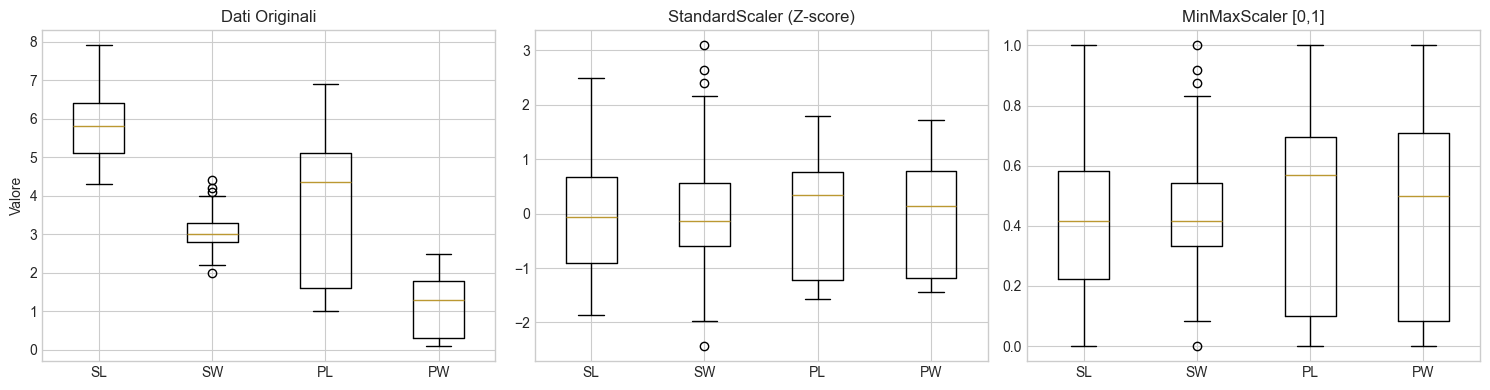

In [ ]:
# Graphical comparison of original, standardized, and normalized data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].boxplot([X[:, i] for i in range(4)], tick_labels=['SL', 'SW', 'PL', 'PW'])
axes[0].set_title('Dati Originali')
axes[0].set_ylabel('Valore')

# StandardScaler
axes[1].boxplot([X_standardized[:, i] for i in range(4)], tick_labels=['SL', 'SW', 'PL', 'PW'])
axes[1].set_title('StandardScaler (Z-score)')

# MinMaxScaler
axes[2].boxplot([X_normalized[:, i] for i in range(4)], tick_labels=['SL', 'SW', 'PL', 'PW'])
axes[2].set_title('MinMaxScaler [0,1]')

plt.tight_layout()
plt.show()

### 3.2 Dimensionality Reduction (PCA)

In [ ]:
# PCA - Principal Component Analysis
# Reduce from 4 to 2 dimensions for visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)

print("PCA - Dimensionality Reduction from 4 to 2 Components")
print(f"\nExplained Variance per Component: {pca.explained_variance_ratio_.round(4)}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

PCA - Riduzione dimensionalità da 4 a 2 componenti

Varianza spiegata per componente: [0.7296 0.2285]
Varianza totale spiegata: 95.81%


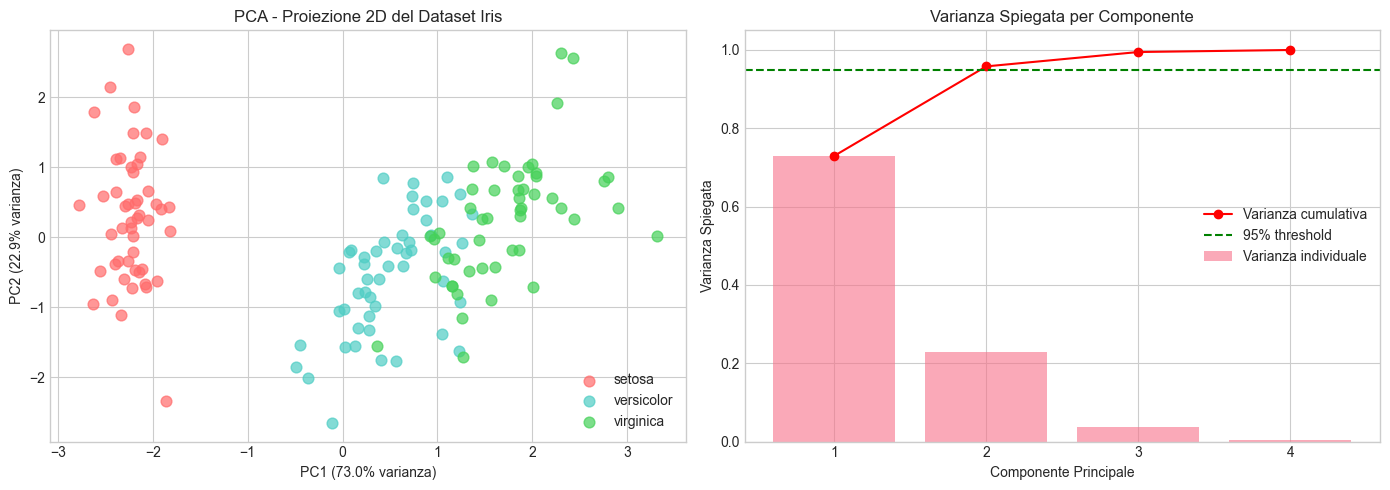

In [ ]:
# PCA Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot of the principal components
colors = ['#FF6B6B', '#4ECDC4', "#45D158"]
for i, species in enumerate(iris.target_names):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], # x axis (rows for which mask is true, first component of PCA)
                    X_pca[mask, 1], # y axis (rows for which mask is true, second component of PCA)
                    c=colors[i],
                    label=species,
                    alpha=0.7, # transparency
                    s=60 # point size
                    )
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].set_title('PCA - Proiezione 2D del Dataset Iris')
axes[0].legend()

# Cumulative variance plot
pca_full = PCA().fit(X_standardized)
# pca_full.explained_variance_ratio_ è un array con la percentuale di varianza spiegata da ogni componente, ad esempio: [0.72, 0.23, 0.04, 0.01]
# np.cumsum(...) calcola la somma cumulativa: [0.72, 0.95, 0.99, 1.0]
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual Variance')
axes[1].plot(range(1, 5), cumsum, 'ro-', label='Cumulative Variance')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance')
axes[1].set_title('Explained Variance by Component')
axes[1].legend()
axes[1].set_xticks(range(1, 5))

plt.tight_layout()
plt.show()

### 3.3 Feature Selection

In [43]:
# SelectKBest - Selezione delle K migliori feature
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, y)

# Punteggi delle feature
feature_scores = pd.DataFrame({
    'Feature': iris.feature_names,
    'Score': selector.scores_,
    'Selected': selector.get_support()
}).sort_values('Score', ascending=False)

print("Feature Selection - SelectKBest (ANOVA F-test)")
print(feature_scores)

Feature Selection - SelectKBest (ANOVA F-test)
             Feature        Score  Selected
2  petal length (cm)  1180.161182      True
3   petal width (cm)   960.007147      True
0  sepal length (cm)   119.264502     False
1   sepal width (cm)    49.160040     False


The previous cell automatically selects the 2 best features for classifying the data.

#### Creating the selector

`SelectKBest(score_func=f_classif, k=2)`

- `k=2` — we want to keep only 2 features
- `score_func=f_classif` — uses the ANOVA F-test to calculate how useful each feature is for distinguishing between classes (the species)

#### Feature selection

`selector.fit_transform(X, y)`

Analyzes all features, ranks them by importance, and returns only the 2 best ones. `X_selected` will have only 2 columns instead of 4.

#### Useful attributes

`selector.scores_` — array with the score of each feature. Higher = more useful for classification.

`selector.get_support()` — boolean array indicating which features were selected.

#### The final DataFrame

Creates a table sorted by score:

| Feature | Score | Selected |
|---------|-------|----------|
| petal length | 1180.16 | True |
| petal width | 960.01 | True |
| sepal length | 119.26 | False |
| sepal width | 49.16 | False |

#### What it is used for

If you have many features, you can use SelectKBest to keep only the most informative ones and discard noise, making the model simpler and often more effective.

<details>
<summary>What type of feature selection did we use?</summary>
This is a **filter method** because it evaluates features statistically, without knowing which model we will use afterwards. It differs from **wrapper methods**, which use a specific model to select features.
</details>

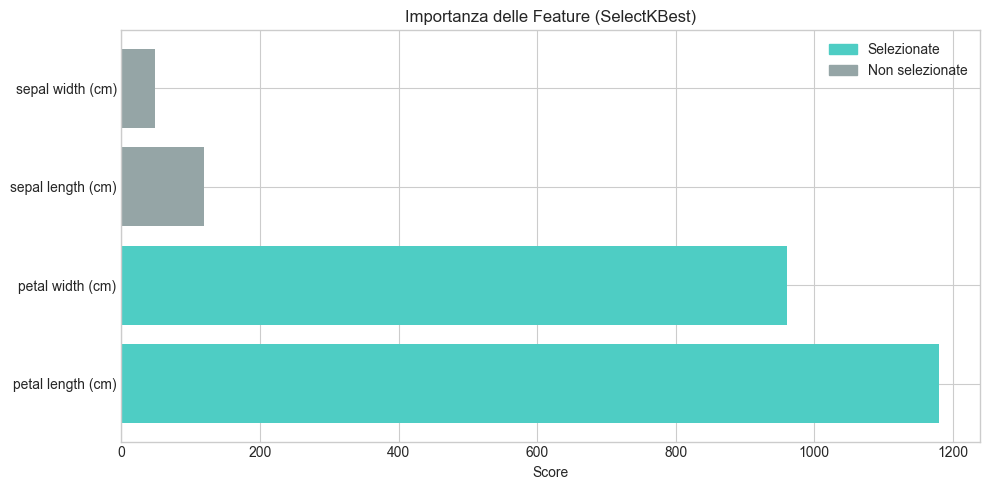

In [ ]:
# Feature Importance visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4ECDC4' if s else '#95a5a6' for s in feature_scores['Selected']]
bars = ax.barh(feature_scores['Feature'], feature_scores['Score'], color=colors)
ax.set_xlabel('Score')
ax.set_title('Importance of Features (SelectKBest)')
ax.legend(handles=[plt.Rectangle((0,0),1,1, color='#4ECDC4'), 
                   plt.Rectangle((0,0),1,1, color='#95a5a6')],
          labels=['Selected', 'Not Selected'])
plt.tight_layout()
plt.show()

### 3.4 Correlation matrix

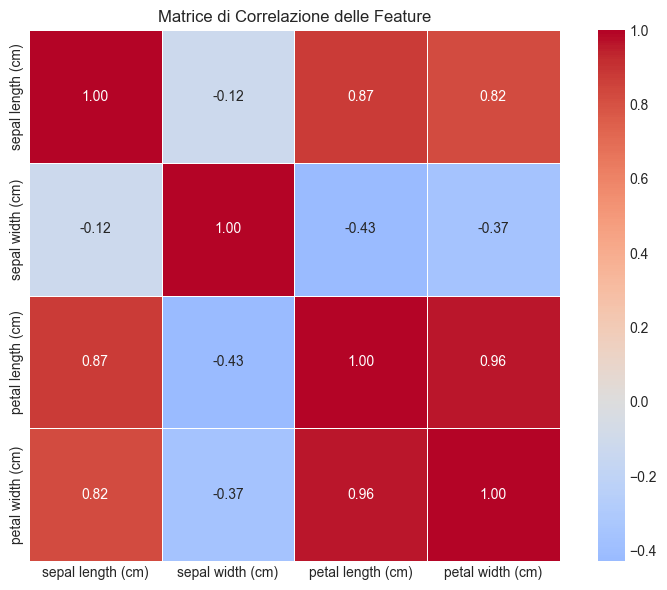

In [ ]:
# Correlation matrix
correlation_matrix = df[iris.feature_names].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f', ax=ax)
ax.set_title('Matrice di Correlazione delle Feature')
plt.tight_layout()
plt.show()

---
## PHASE 4: Data Mining

Applying machine learning algorithms to extract patterns from data.

### 4.1 Dataset Split

In [ ]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, y, 
    test_size=0.3,      # 30% for test
    random_state=42,    # Reproducibility
    stratify=y          # keep class proportions
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass distribution in the training set: {np.bincount(y_train)}")
print(f"Class distribution in the test set: {np.bincount(y_test)}")

Training set: 105 campioni
Test set: 45 campioni

Distribuzione classi nel training set: [35 35 35]
Distribuzione classi nel test set: [15 15 15]


### 4.2 Classification - Supervised Algorithm

In [ ]:
# Let's define several classifiers to compare
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB()
}

# Training and evaluation of classifiers
results = []

for name, clf in classifiers.items():
    # Training
    clf.fit(X_train, y_train)
    
    # Prediction
    y_pred = clf.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Modello': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("Confronto Classificatori:")
print(results_df.to_string(index=False))

Confronto Classificatori:
               Modello  Accuracy  Precision   Recall  F1-Score
         Decision Tree  0.933333   0.944444 0.933333  0.932660
   K-Nearest Neighbors  0.911111   0.929825 0.911111  0.909502
Support Vector Machine  0.911111   0.915535 0.911111  0.910714
           Naive Bayes  0.911111   0.915535 0.911111  0.910714
         Random Forest  0.888889   0.898148 0.888889  0.887767


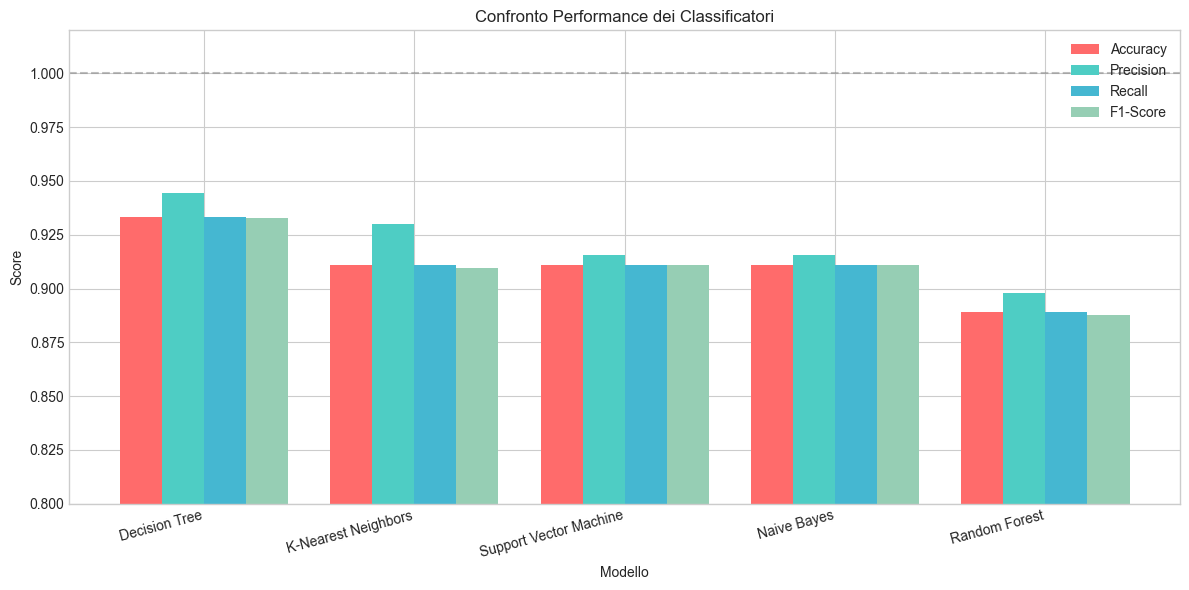

In [ ]:
# Visualization and perdormance comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color)

ax.set_xlabel('Modello')
ax.set_ylabel('Score')
ax.set_title('Confronto Performance dei Classificatori')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Modello'], rotation=15, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0.8, 1.02)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4.3 Decision Tree Visualization

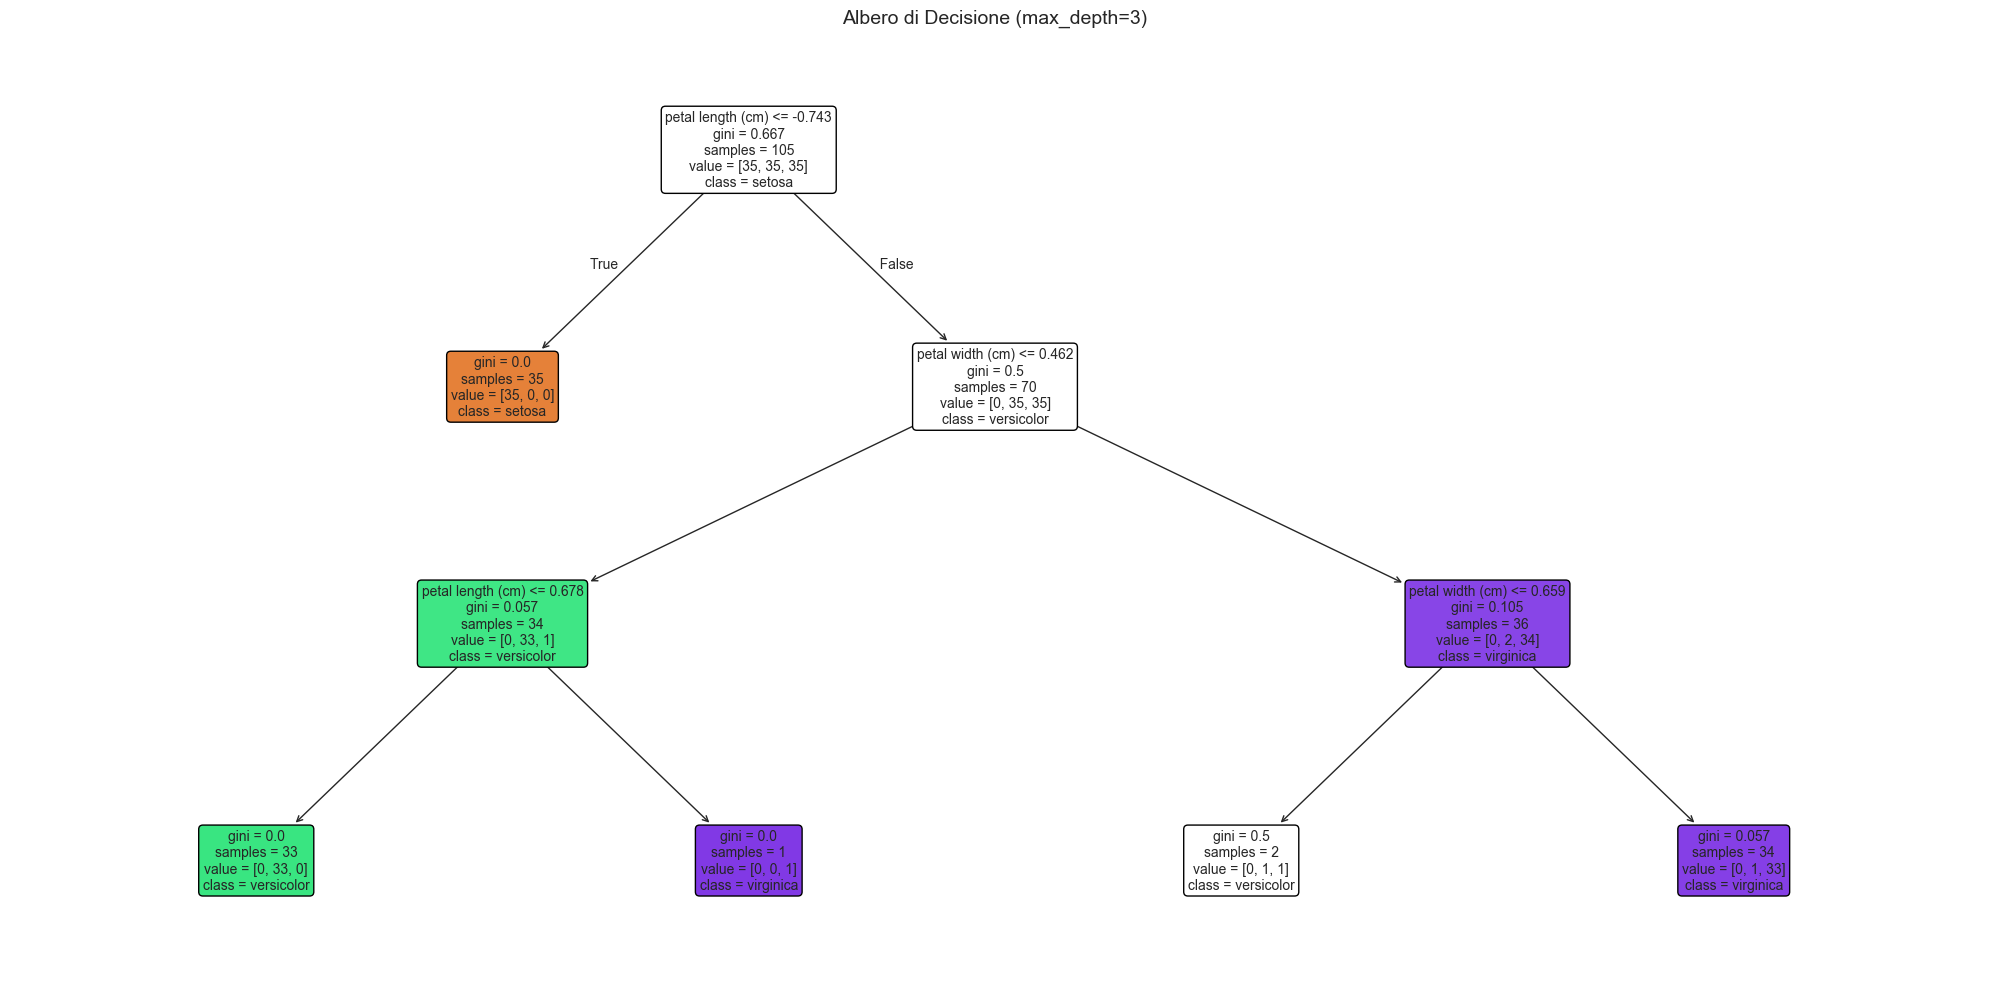

In [51]:
# Decision Tree con profondità limitata per visualizzazione
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_viz, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
plt.title('Albero di Decisione (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Feature Importance (Random Forest)

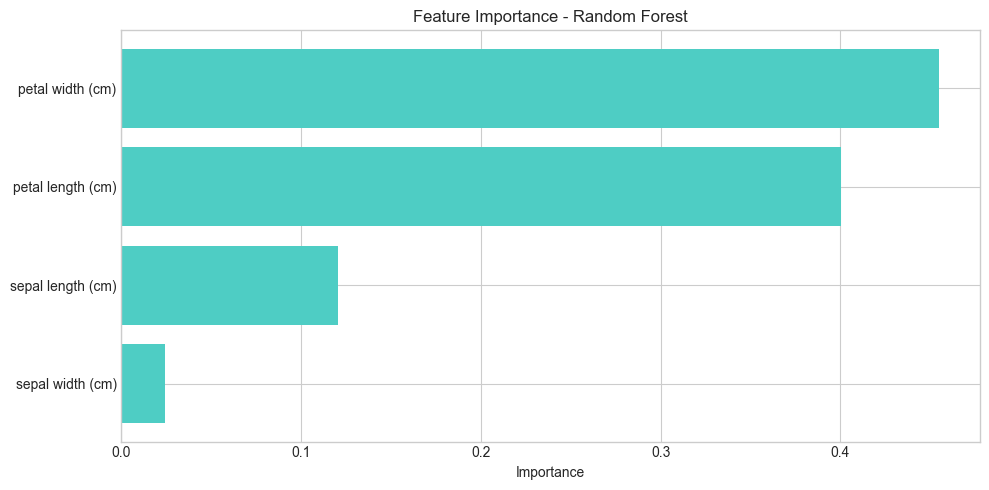

In [52]:
# Feature importance dal Random Forest
rf = classifiers['Random Forest']
importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#4ECDC4')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

---
## PHASE 5: Interpretation and Evaluation

In-depth analysis of results and model validation.

### 5.1 Confusion Matrix

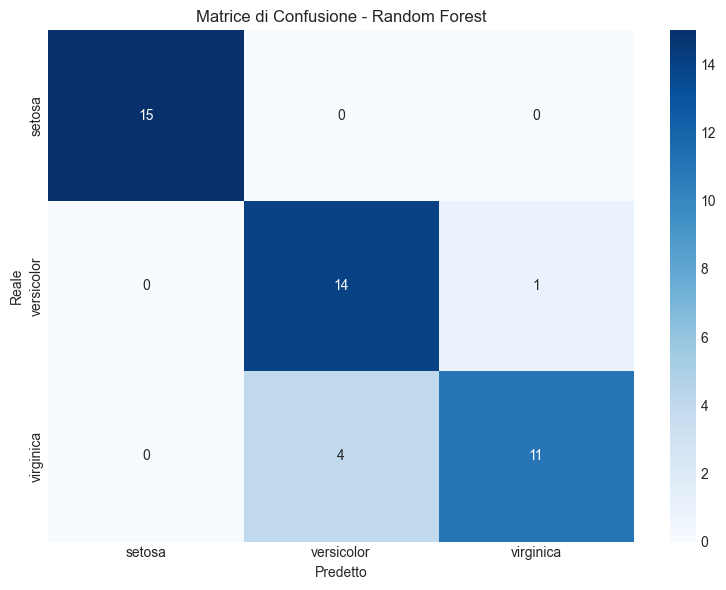

In [55]:
# Matrice di confusione per il miglior modello
best_clf = classifiers['Random Forest']
y_pred_best = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, # mostra i numeri nelle celle
            fmt='d', # formato intero
            cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names, ax=ax)
ax.set_xlabel('Predetto')
ax.set_ylabel('Reale')
ax.set_title('Matrice di Confusione - Random Forest')
plt.tight_layout()
plt.show()

In [56]:
# Report di classificazione dettagliato
print("Classification Report - Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

Classification Report - Random Forest
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



### 5.2 Cross-Validation

In [57]:
# Cross-validation per tutti i modelli
print("Cross-Validation (5-fold)")
print("=" * 50)

cv_results = []
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_standardized, y, cv=5, scoring='accuracy')
    cv_results.append({
        'Modello': name,
        'Media': scores.mean(),
        'Std': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

cv_df = pd.DataFrame(cv_results).sort_values('Media', ascending=False)

Cross-Validation (5-fold)
Decision Tree: 0.953 (+/- 0.068)
Random Forest: 0.967 (+/- 0.042)
K-Nearest Neighbors: 0.960 (+/- 0.050)
Support Vector Machine: 0.967 (+/- 0.042)
Naive Bayes: 0.953 (+/- 0.053)


In [ ]:
# Visualizzazione cross-validation
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cv_df))
bars = ax.bar(x, cv_df['Media'], yerr=cv_df['Std'], 
              color='#4ECDC4', alpha=0.8, capsize=5)
ax.set_xlabel('Modello')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation: Accuracy Media ± Std')
ax.set_xticks(x)
ax.set_xticklabels(cv_df['Modello'], rotation=15, ha='right')
ax.set_ylim(0.85, 1.02)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Aggiungi valori sopra le barre
for i, (bar, mean, std) in enumerate(zip(bars, cv_df['Media'], cv_df['Std'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3 Hyperparameter Tuning (GridSearchCV)

In [ ]:
# Grid Search per Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_standardized, y)

print("GridSearchCV - Random Forest")
print("=" * 50)
print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior score (CV): {grid_search.best_score_:.4f}")

In [ ]:
# Valutazione del modello ottimizzato
best_rf = grid_search.best_estimator_
y_pred_optimized = best_rf.predict(X_test)

print("\nPerformance del modello ottimizzato sul test set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_optimized, average='weighted'):.4f}")